# BENCHMARK 2

Reentrenamiento de los modelos U-Net, DeepLabV3+ y SegFormer con el Dataset CityScape.

In [ ]:
import os
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import Cityscapes

import albumentations as A                      

import cv2
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.segmentation import MeanIoU
from torchmetrics import JaccardIndex

import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation, SegformerConfig

from torch.amp import autocast, GradScaler

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

In [ ]:
CONFIG = {
    "epochs": 2,
    "batch": 6,
    "num_clases": 19,
    "seed": 42,
    "data": '../data/cityscape',
    "checkpoint_dir": "../checkpoints/benchmark2/",
    "logs_dir": "../logs/benchmark2/",
    "mem_dir": "../memoria/benchmark2/"
}

HIPER_UN = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}

HIPER_DL = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}

HIPER_SF = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]



torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])


# Crear carpetas necesarias
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
os.makedirs(CONFIG["logs_dir"], exist_ok=True)
os.makedirs(CONFIG["mem_dir"], exist_ok=True)

In [3]:
#### GPU Info ####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
CROP_SIZE = 512   #  512, 768 o 1024

transform_train = A.Compose([
    # Escalado aleatorio sobre la imagen original (multi-scale training)
    A.RandomScale(scale_limit=(-0.5, 1.0), p=1.0,
                  interpolation=cv2.INTER_LINEAR),
    
    # Padding por si el escalado dejó algún lado menor que CROP_SIZE
    A.PadIfNeeded(
        min_height=CROP_SIZE,
        min_width=CROP_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=255
    ),
    
    # Recorte cuadrado aleatorio (NO panorámico, para que entre en VRAM)
    A.RandomCrop(CROP_SIZE, CROP_SIZE),
    
    # Augmentations
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.0, p=0.5),
    
    # Normalización
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])


transform_val = A.Compose([
    A.Resize(512, 1024,
             interpolation=cv2.INTER_LINEAR,
             mask_interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

In [5]:
"""
names:
  0: road
  1: sidewalk
  2: building
  3: wall
  4: fence
  5: pole
  6: traffic light
  7: traffic sign
  8: vegetation
  9: terrain
  10: sky
  11: person
  12: rider
  13: car
  14: truck
  15: bus
  16: train
  17: motorcycle
  18: bicycle
"""

"""
label_mapping:
  -1: ignore_label
  0: ignore_label
  1: ignore_label
  2: ignore_label
  3: ignore_label
  4: ignore_label
  5: ignore_label
  6: ignore_label
  7: 0
  8: 1
  9: ignore_label
  10: ignore_label
  11: 2
  12: 3
  13: 4
  14: ignore_label
  15: ignore_label
  16: ignore_label
  17: 5
  18: ignore_label
  19: 6
  20: 7
  21: 8
  22: 9
  23: 10
  24: 11
  25: 12
  26: 13
  27: 14
  28: 15
  29: ignore_label
  30: ignore_label
  31: 16
  32: 17
  33: 18
"""

'\nlabel_mapping:\n  -1: ignore_label\n  0: ignore_label\n  1: ignore_label\n  2: ignore_label\n  3: ignore_label\n  4: ignore_label\n  5: ignore_label\n  6: ignore_label\n  7: 0\n  8: 1\n  9: ignore_label\n  10: ignore_label\n  11: 2\n  12: 3\n  13: 4\n  14: ignore_label\n  15: ignore_label\n  16: ignore_label\n  17: 5\n  18: ignore_label\n  19: 6\n  20: 7\n  21: 8\n  22: 9\n  23: 10\n  24: 11\n  25: 12\n  26: 13\n  27: 14\n  28: 15\n  29: ignore_label\n  30: ignore_label\n  31: 16\n  32: 17\n  33: 18\n'

In [6]:
ID_TO_TRAINID = {
    -1: 255,   # license plate
    0: 255,  # unlabeled
    1: 255,  # ego vehicle
    2: 255,  # rectification border
    3: 255,  # out of roi
    4: 255,  # static
    5: 255,  # dynamic
    6: 255,  # ground
    7: 0,    # road
    8: 1,    # sidewalk
    9: 255,  # parking
    10: 255,  # rail track
    11: 2,    # building
    12: 3,    # wall
    13: 4,    # fence
    14: 255,  # guard rail
    15: 255,  # bridge
    16: 255,  # tunnel
    17: 5,    # pole
    18: 255,  # polegroup
    19: 6,    # traffic light
    20: 7,    # traffic sign
    21: 8,    # vegetation
    22: 9,    # terrain
    23: 10,   # sky
    24: 11,   # person
    25: 12,   # rider
    26: 13,   # car
    27: 14,   # truck
    28: 15,   # bus
    29: 255,  # caravan
    30: 255,  # trailer
    31: 16,   # train
    32: 17,   # motorcycle
    33: 18    # bicycle
}

In [ ]:
LUT = np.full(34, 255, dtype=np.uint8)
for id_original, train_id in ID_TO_TRAINID.items():
    if id_original >= 0:
        LUT[id_original] = train_id


def convert_mask_id(mask):
    """Convierte máscara con IDs originales de Cityscapes a trainIds."""
    mask = np.asarray(mask, dtype=np.int32)
    
    mask = np.clip(mask, 0, 33)  # protege contra valores inesperados
    return LUT[mask]

In [8]:
class Dataset_Cityscape(Dataset):

    def __init__(self, conjunto="train", transform=None):
        self.dataset = Cityscapes(
            root=CONFIG["data"],
            split=conjunto,
            mode="fine",
            target_type="semantic"
        )
        self.transform=transform

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indice:int):
        image, mask = self.dataset[indice]

        image = np.array(image)
        mask = np.array(mask)

        mask = convert_mask_id(mask)
        mask = mask.astype(np.uint8)

        if self.transform:
            t = self.transform(image=image, mask=mask)
            image = t["image"]
            mask = t["mask"].long()
        return image, mask
        

In [ ]:
train_data = Dataset_Cityscape(conjunto="train", transform=transform_train)
val_data = Dataset_Cityscape(conjunto="val", transform=transform_val)


In [10]:
img, mascara = train_data[0]
img.shape[-2:]

torch.Size([768, 768])

In [ ]:
train_loader = DataLoader(
    train_data,
    batch_size=CONFIG["batch"],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=CONFIG["batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)



In [ ]:
print(f"N° imágenes de entrenamiento: {len(train_data)} imágenes | {len(train_loader)} batches")
print(f"N° imágene de validación: {len(val_data)} imágenes | {len(val_loader)} batches")

N° imágenes de entrenamiento: 2975 imágenes | 744 batches
N° imágene de validación: 500 imágenes | 125 batches
N° imágene de test: 1525 imágenes | 1525 batches

(CityScape) Número total del imágenes 5000


In [13]:
r = set()
for i in ID_TO_TRAINID.values():
    r.add(i)

print(f"El dataset CityScape tiene {len(r)} clases distintas.\n19 objetos y el fondo")
print(r)

El dataset CityScape tiene 20 clases distintas.
19 objetos y el fondo
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 255}


In [14]:
COLOR_DIC = {
    0:[128,0,0],
    1:[0,128,0],
    2:[128,128,0],
    3:[0,0,128],
    4:[128,0,128],
    5:[0,128,128],
    6:[128,128,128],
    7:[64,0,0],
    8:[0,200,0],
    9:[192,0,0],
    10:[64,128,0],
    11:[192,128,0],
    12:[64,0,128],
    13:[192,0,128],
    14:[64,128,128],
    15:[192,128,128],
    16:[0,64,0],
    17:[128,64,0],
    18:[0,192,0],
    255: [0,0,0]
}

In [15]:
def colorear_mascara(mask):
    mask_color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for k, v in COLOR_DIC.items():
        mask_color[mask == k] = v
    return mask_color

In [16]:
def desnormalizar(tensor):
    mean = torch.tensor(MEAN).view(3,1,1)
    std = torch.tensor(STD).view(3,1,1)
    return (tensor*std+mean).clamp(0,1)

In [17]:
def visualizar_ejemplos(loader, n=4):
    images, masks = next(iter(loader))
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

    for i in range(n):
        img = desnormalizar(images[i]).permute(1,2,0).numpy()
        axes[0,i].imshow(img)
        axes[0,i].set_title("Imagen")
        axes[0,i].axis("off")

        axes[1,i].imshow(colorear_mascara(masks[i].numpy()))
        axes[1,i].set_title("Máscara")
        axes[1,i].axis("off")

    plt.suptitle("Ejemplos CityScape", fontsize=14)
    plt.tight_layout()
    plt.show()

Shape imágenes:  torch.Size([4, 3, 768, 768])
Shape máscaras:  torch.Size([4, 768, 768])
Clases únicas:   tensor([  0,   1,   2,   4,   5,   6,   7,   8,   9,  10,  11,  13,  15, 255])


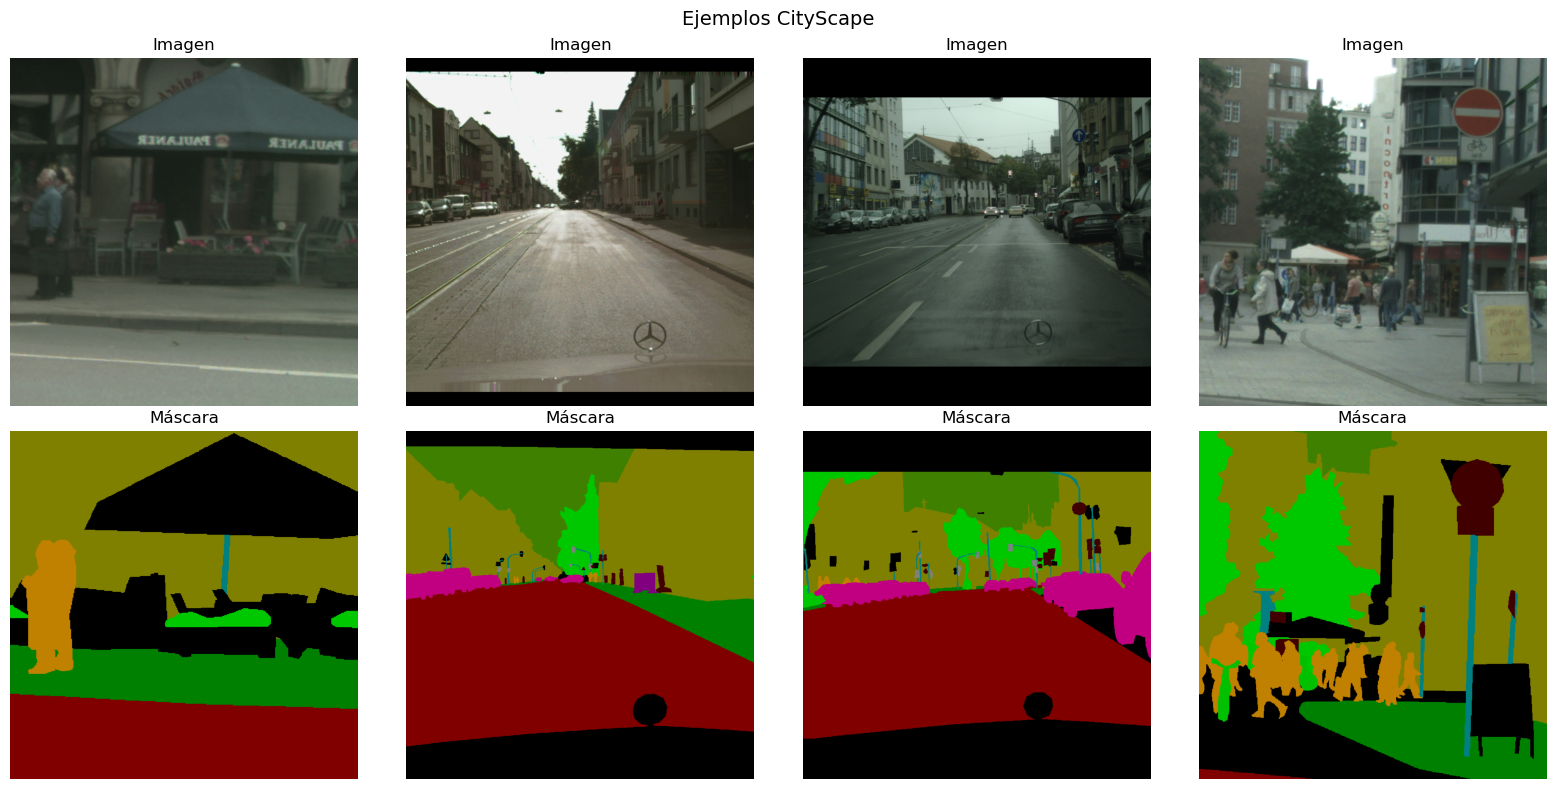

In [18]:
# Verificar shapes
images, masks = next(iter(train_loader))
print(f"Shape imágenes:  {images.shape}")
print(f"Shape máscaras:  {masks.shape}")
print(f"Clases únicas:   {masks.unique()}")

# Visualizar
visualizar_ejemplos(train_loader)

## Definir modelos.

In [19]:
# ── U-Net ──────────────────────────────────────
unet = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_unet(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:], 
                           mode="bilinear", align_corners=False)
    return out

print(f"** U-Net -> N° parámetros: {sum(p.numel() for p in unet.parameters())/1e6:.1f}M")
print("\n** Modelo U-Net cargado")

** U-Net -> N° parámetros: 32.5M

** Modelo U-Net cargado


In [20]:
# ── DeepLabV3+ ──────────────────────────────────
deeplabv3plus = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_deeplabv3plus(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:],
                           mode="bilinear", align_corners=False)
    return out

print(f"\n** DeepLabV3Plus -> N° parámetros: {sum(p.numel() for p in deeplabv3plus.parameters())/1e6:.1f}M")
print("\n** Modelo DeepLabV3Plus cargado")


** DeepLabV3Plus -> N° parámetros: 26.7M

** Modelo DeepLabV3Plus cargado


In [21]:
# ── SegFormer ──────────────────────────────────
segformer = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)

def forward_segformer(model, images):
    outputs = model(pixel_values=images)
    return F.interpolate(
        outputs.logits,
        size=images.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

print(f"\n\n\n** SegFormer -> N° parámetros: {sum(p.numel() for p in segformer.parameters())/1e6:.1f}M")
print("\n** Modelo SegFormer cargado")

[transformers] You passed `num_labels=19` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr




** SegFormer -> N° parámetros: 27.4M

** Modelo SegFormer cargado


### Definición función de pérdida

In [22]:
class perdidaDiceCE(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(
            mode="multiclass",
            ignore_index=255
        )
        self.ce = nn.CrossEntropyLoss(ignore_index=255)

    def forward(self, pred, obj):
        return 0.5 * self.dice(pred, obj) + 0.5 * self.ce(pred, obj)

loss_fn = perdidaDiceCE()
print("-> Función de pérdida definida")

-> Función de pérdida definida


In [ ]:
def entrenar_modelo(modelo, nombre, forward_fn, hiper):

    ############################
    # Reset de semilla
    torch.manual_seed(CONFIG["seed"])
    np.random.seed(CONFIG["seed"])
    ############################

    modelo = modelo.to(device)
    
    writer  = SummaryWriter(log_dir=f"../logs/benchmark2/{nombre}")

    miou_fn = JaccardIndex(

        task="multiclass",
        num_classes=CONFIG["num_clases"],
        ignore_index=255,
        average="macro"

    ).to(device)
    
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, modelo.parameters()),
        lr=hiper["lr"],
        weight_decay=hiper["weight_decay"]
    )
    """ 
    # Actualización de la tasa de aprendizaje.##############
    """
    scheduler_step_per_iter=False
    if (nombre == "unet"):
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG["epochs"], eta_min=1e-6
        )
        scheduler_step_per_iter = False

    elif(nombre == "deeplabv3plus"):
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer,
            total_iters=CONFIG["epochs"] * len(train_loader),
            power=0.9
        )
        scheduler_step_per_iter = True

    else:
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer,
            total_iters=CONFIG["epochs"] * len(train_loader),
            power=1.0
        )
        scheduler_step_per_iter = True
    
    """ 
    ########################################################
    """

    scaler = GradScaler("cuda")
    
    historial = {
        "loss_train": [],
        "miou_val":   []
    }

    tiempo_entrenamiento = 0.0
    mejor_miou = 0.0
    
    for epoch in range(CONFIG["epochs"]):

        # Aquí empieza el entrenamiento de cada epoch
        inicio_epoch = time.time()
        # -- Train ---------------------------
        modelo.train()
        loss_total = 0

        pbar = tqdm(
            train_loader,
            desc=f"[{nombre}] Epoch {epoch+1}/{CONFIG['epochs']}",
            leave=False
        )

        for images, masks in pbar:
            images = images.to(device, non_blocking=True)
            masks = masks.long().to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast("cuda"):
                preds = forward_fn(modelo, images)
                loss = loss_fn(preds, masks)


            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            if scheduler_step_per_iter:
                scheduler.step()

            loss_total += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")


        loss_media = loss_total / len(train_loader)

        

        # -- Validación ---------------------------
        modelo.eval()
        miou_fn.reset()

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks  = masks.long().to(device)
                preds  = forward_fn(modelo, images).argmax(dim=1)
                miou_fn.update(preds, masks)


        miou_val = miou_fn.compute().item()   
            

        tiempo_epoch = (time.time() - inicio_epoch)/60 # tiempo en min del entrenamiento de cada epochs.
        # -- Sumar tiempo epoch ---------------------------
        tiempo_entrenamiento += tiempo_epoch    # Sumo tiempo de epoch.

        # -- Guardar historial ---------------------------
        historial["loss_train"].append(loss_media)
        historial["miou_val"].append(miou_val)
        
        # -- TensorBoard ---------------------------
        writer.add_scalar("Loss/train", loss_media, epoch)
        writer.add_scalar("mIoU/val", miou_val, epoch)
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)
        writer.add_scalar("Tiempo/epoch", tiempo_epoch, epoch)

        print(f"[{nombre}] Epoch {epoch+1:02d} | Loss: {loss_media:.4f} | mIoU: {miou_val*100:.2f}% | Tiempo: {tiempo_epoch:.4f} min")

        # -- Guardar mejor modelo ---------------------------
        if miou_val > mejor_miou:
            mejor_miou = miou_val
            torch.save({
                "epoch":          epoch,
                "modelo":         modelo.state_dict(),
                "optimizer":      optimizer.state_dict(),
                "scheduler":      scheduler.state_dict(),
                "mejor_miou":     mejor_miou,
                "historial":      historial
            },
            f"{CONFIG['checkpoint_dir']}{nombre}_b2_checkpoint.pth"
            )
            print(f"  -- Guardado modelo {nombre} con mIoU = {mejor_miou*100:.2f}%")

        if not scheduler_step_per_iter:
            scheduler.step()   # disminuye learning rate.
    
    writer.close()
    
    print(f"\n\n-->>    {nombre} completado | Mejor mIoU: {mejor_miou*100:.2f}% | Tiempo total de entrenamiento: {tiempo_entrenamiento:.2f} min   <<--")
    
    #--- Libero memoria VRAM ------------------
    modelo.cpu()
    del modelo
    del optimizer
    del scheduler
    del miou_fn
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    #--------------------------------
    
    return mejor_miou, historial, tiempo_entrenamiento

In [ ]:
# Entrenar U-net
miou_unet, hist_unet, tiempo_en_unet = entrenar_modelo(
    modelo=unet, nombre="unet", forward_fn=forward_unet, hiper=HIPER_UN
)

[unet] Epoch 1/2:   0%|          | 0/744 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
#Entrenar DeepLabV3Plus
miou_deeplabv3plus, hist_deeplabv3plus, tiempo_en_deeplab = entrenar_modelo(
    modelo=deeplabv3plus, nombre="deeplabv3plus", forward_fn=forward_deeplabv3plus, hiper=HIPER_DL
)

[deeplabv3plus] Epoch 1/2:   0%|          | 0/496 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Entrenar SegFormer
miou_segformer, hist_segformer, tiempo_en_segformer = entrenar_modelo(
    modelo=segformer, nombre="segformer", forward_fn=forward_segformer, hiper=HIPER_SF
)

[segformer] Epoch 1/2:   0%|          | 0/744 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 432.00 MiB. GPU 0 has a total capacity of 7.62 GiB of which 87.19 MiB is free. Including non-PyTorch memory, this process has 7.52 GiB memory in use. Of the allocated memory 7.34 GiB is allocated by PyTorch, and 55.55 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

# Visualización datos de entrenamiento

In [ ]:
"""
ALMACENAR MEJOR mIoU ENTRENAMIENTO.
"""
res_mejor=[]
mejor_unet={"Modelo":"U-Net", 
            "Mejor mIoU(%) entrenamiento":round(miou_unet*100,2), 
            "Tiempo entrenamiento (min)":round(tiempo_en_unet,2)}
res_mejor.append(mejor_unet)

mejor_deeplabv3plus={"Modelo":"DeepLabV3plus",
                     "Mejor mIoU(%) entrenamiento":round(miou_deeplabv3plus*100,2),
                     "Tiempo entrenamiento (min)":round(tiempo_en_deeplab,2)}
res_mejor.append(mejor_deeplabv3plus)

mejor_segformer={"Modelo":"SegFormer",
                 "Mejor mIoU(%) entrenamiento":round(miou_segformer*100,2),
                 "Tiempo entrenamiento (min)":round(tiempo_en_segformer,2)}
res_mejor.append(mejor_segformer)


t = pd.DataFrame(res_mejor)
display(t)

In [ ]:
t.to_csv(CONFIG["mem_dir"]+"resultados_b2_entrenamiento.csv")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas mIoU
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[0].plot(hist["miou_val"], label=nombre)

axes[0].set_title("mIoU Validación por Epoch (Benchmark 2)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mIoU")
axes[0].legend()
axes[0].xaxis.set_major_locator(plt.MultipleLocator(2))
axes[0].grid(True)

# Curvas Loss
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[1].plot(hist["loss_train"], label=nombre)

axes[1].set_title("Loss Train por Epoch (Benchmark 2)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].xaxis.set_major_locator(plt.MultipleLocator(2))
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../memoria/benchmark2/curvas_entrenamiento_b2.png", dpi=150)
plt.show()

# Datos de test.

In [ ]:
transform_test = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

In [ ]:
test_data = Dataset_Cityscape(conjunto="test", transform=transform_test)

In [ ]:
test_loader = DataLoader(
    test_data,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Evaluación modelos entrenados

In [ ]:
def calcular_tamano_modelo(modelo):
    """
    Calcula el tamaño del modelo en MB sumando el tamaño en bytes
    de todos los parámetros y buffers.
    """
    param_size = sum(p.numel() * p.element_size() for p in modelo.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in modelo.buffers())
    total_mb = (param_size + buffer_size) / (1024 ** 2)
    return total_mb

In [ ]:
def evaluar_final(nombre, modelo, forward_fn):
    # Cargar checkpoint
    checkpoint = torch.load(
        f"{CONFIG['checkpoint_dir']}{nombre}_b2_checkpoint.pth",
        map_location=device
    )
    modelo.load_state_dict(checkpoint["modelo"])   #<- modelo entrenado
    modelo.eval()
    modelo = modelo.to(device)
    
    print(f"{nombre} cargado | mIoU guardado: {checkpoint['mejor_miou']*100:.2f}%")

    
    miou_fn = JaccardIndex(
        task="multiclass",
        num_classes=CONFIG["num_clases"],
        ignore_index=255,
        average="macro"
    ).to(device)
    
    tiempos = []
    n_params = sum(p.numel() for p in modelo.parameters()) / 1e6
    
    # Tamaño del modelo en disco/memoria
    tam_mb = calcular_tamano_modelo(modelo)

    # Warmup de GPU
    with torch.no_grad():
        dummy = next(iter(test_loader))[0][:1].to(device)
        for _ in range(5):
            _ = forward_fn(modelo, dummy)
    torch.cuda.synchronize()

    # Evaluación real
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.long().to(device)
            batch_size = images.shape[0]

            torch.cuda.synchronize()
            inicio = time.time()
            preds = forward_fn(modelo, images).argmax(dim=1)
            torch.cuda.synchronize()
            fin = time.time()

            # Tiempo POR IMAGEN (dividir entre el tamaño del batch)
            tiempos.append((fin - inicio) / batch_size)
            miou_fn.update(preds, masks)

    miou = miou_fn.compute().item()
    fps = 1.0 / np.mean(tiempos)

    modelo.cpu()
    del modelo, miou_fn
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    return {
        "Modelo": nombre,
        "mIoU (%)": round(miou * 100, 2),
        "FPS": round(fps, 1),
        "Params (M)": round(n_params, 1),
        "Tamaño (MB)": round(tam_mb, 1)
    }

In [ ]:
unet_val = smp.Unet(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=CONFIG["num_clases"]
)
def forward_unet_val(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:], 
                           mode="bilinear", align_corners=False)
    return out

In [ ]:
deeplabv3plus_val = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=CONFIG["num_clases"]
)
def forward_deeplabv3plus_val(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:],
                           mode="bilinear", align_corners=False)
    return out

In [ ]:
config_s = SegformerConfig.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)
segformer_val = SegformerForSemanticSegmentation(config_s)
def forward_segformer_val(model, images):
    outputs = model(pixel_values=images)
    return F.interpolate(
        outputs.logits,
        size=images.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

In [ ]:
# Evaluar todos los modelos.
resultados = []

res = evaluar_final("unet", unet, forward_unet)
resultados.append(res)

res = evaluar_final("deeplabv3plus", deeplabv3plus, forward_deeplabv3plus)
resultados.append(res)

res = evaluar_final("segformer", segformer, forward_segformer)
resultados.append(res)



# Tabla comparativa
df = pd.DataFrame(resultados).sort_values("mIoU (%)", ascending=False)
display(df)
df.to_csv("../memoria/benchmark2/resultados_finales_b2.csv", index=False)

# Visualización de modelos entrenados.

In [ ]:
unet_vis = smp.Unet(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=CONFIG["num_clases"]
)
def forward_unet_vis(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:], 
                           mode="bilinear", align_corners=False)
    return out
#####################################################################
deeplabv3plus_vis = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=CONFIG["num_clases"]
)
def forward_deeplabv3plus_vis(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:],
                           mode="bilinear", align_corners=False)
    return out
#####################################################################
config_s = SegformerConfig.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)
segformer_vis = SegformerForSemanticSegmentation(config_s)
def forward_segformer_vis(model, images):
    outputs = model(pixel_values=images)
    return F.interpolate(
        outputs.logits,
        size=images.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

In [ ]:
def cargar_modelo(nombre, modelo):
    
    checkpoint = torch.load(
        f"{CONFIG['checkpoint_dir']}{nombre}_b2_checkpoint.pth",
        map_location=device
    )
    modelo.load_state_dict(checkpoint["modelo"])
    modelo.eval()
    modelo.to(device)
    return modelo

In [ ]:
"""
names:
  0: road
  1: sidewalk
  2: building
  3: wall
  4: fence
  5: pole
  6: traffic light
  7: traffic sign
  8: vegetation
  9: terrain
  10: sky
  11: person
  12: rider
  13: car
  14: truck
  15: bus
  16: train
  17: motorcycle
  18: bicycle
"""

In [ ]:
# Lista de clases de Cityscapes en orden de trainId (0-18)
CITYSCAPES_CLASES = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation", "terrain",
    "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]

In [ ]:
def visualizar_prediccion(modelo, forward_fn, dataset, indice=0):
    """
    Muestra imagen original, máscara ground truth y predicción del modelo.
    Los píxeles ignore (255) del GT se muestran en negro.
    Adaptada para Cityscapes (19 clases).
    """

    modelo.eval()
    modelo.to(device)
    
    # Coger una muestra del dataset (ya transformada)
    image, mask = dataset[indice]
    image_batch = image.unsqueeze(0).to(device)
    
    # Predicción
    with torch.no_grad():
        pred = forward_fn(modelo, image_batch).argmax(dim=1).squeeze(0).cpu().numpy()
    
    # Desnormalizar imagen
    img_vis = image.cpu().numpy().transpose(1, 2, 0)
    img_vis = img_vis * np.array(STD) + np.array(MEAN)
    img_vis = np.clip(img_vis, 0, 1)
    
    mask_vis = mask.cpu().numpy()
    
    # Colormap de 19 colores para Cityscapes
    # Combinamos tab20 (descartando 1) para tener exactamente 19 colores distintos
    colores = plt.cm.tab20(np.linspace(0, 1, 20))[:19]   # tomar 19 de 20 colores
    cmap = ListedColormap(colores)
    cmap.set_bad(color="black")                          # los 255 se verán negros
    
    # Enmascarar el 255 en el GT para que salga negro
    mask_plot = np.ma.masked_where(mask_vis == 255, mask_vis)
    
    # Plot — figsize más ancho porque Cityscapes es 2:1 panorámico
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    
    axes[0].imshow(img_vis)
    axes[0].set_title("Imagen")
    axes[0].axis("off")
    
    axes[1].imshow(mask_plot, cmap=cmap, vmin=0, vmax=18)
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")
    
    axes[2].imshow(pred, cmap=cmap, vmin=0, vmax=18)
    axes[2].set_title("Predicción")
    axes[2].axis("off")
    
    # Leyenda con solo las clases presentes (en GT o predicción)
    clases_presentes = sorted(set(np.unique(mask_vis).tolist() + np.unique(pred).tolist()))
    clases_presentes = [c for c in clases_presentes if c != 255]
    handles = [mpatches.Patch(color=cmap(c / 18), label=f"{c}: {CITYSCAPES_CLASES[c]}") 
               for c in clases_presentes]
    fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=9, 
               bbox_to_anchor=(0.5, -0.08))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

In [ ]:
unt = cargar_modelo("unet", unet_vis)
dlv3p = cargar_modelo("deeplabv3plus", deeplabv3plus_vis)
sf = cargar_modelo("segformer", segformer_vis)

In [ ]:
# Visualización U-Net
visualizar_prediccion(modelo=unt, forward_fn=forward_unet_vis, dataset=test_data, indice=0)

In [ ]:
# Visualizar DeepLabv3+
visualizar_prediccion(modelo=dlv3p, forward_fn=forward_deeplabv3plus_vis, dataset=test_data, indice=0)

In [ ]:
# Visualizar SegFormer
visualizar_prediccion(modelo=sf, forward_fn=forward_segformer_vis, dataset=test_data, indice=0)